# 01 - 获取北京历史天气数据

在这个项目中，我们需要分析“降温”对热饮需求的影响。
我们将使用 `meteostat` 库，它封装了历史气象数据 API，可以直接提取结构化的 Pandas DataFrame。

**核心字段说明：**
- `tavg`: 平均气温
- `tmin`: 最低气温
- `tmax`: 最高气温
- `prcp`: 降水量

In [1]:
# !pip install meteostat matplotlib seaborn pandas
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

# 改成更稳的导入方式（避免 from meteostat import ... 在某些版本下失败）
import meteostat as mt
import os

# 1. 设定参数
beijing_location = mt.Point(39.9042, 116.4074, 43.5)

# 历史时间段
start = datetime(2025, 2, 28)
end = datetime(2026, 2, 28)

# 2. 发起请求
data = mt.Daily(beijing_location, start, end)
df = data.fetch()

# 3. 数据处理
print(f'数据行数：{len(df)}')
print(f'列名：{df.columns.tolist()}')
display(df.head())

# 4. 保存数据到指定位置

# 创建完整目录路径（如果不存在）
output_dir = r"C:\Users\Administrator\Desktop\data_learn\Hot-Drink-Retail-Analysis\data\raw"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 指定完整路径保存
file_path = os.path.join(output_dir, 'beijing_weather.csv')
df.to_csv(file_path, index=True, encoding='utf-8-sig')

print(f"数据已保存至: {file_path}")


数据行数：366
列名：['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun']


,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
time,,,,,,,,,,
2025-02-28,9.6,-2.1,19.1,0.0,NaN,77.0,6.0,NaN,1014.3,NaN
2025-03-01,9.7,2.1,19.1,0.0,NaN,78.0,7.8,NaN,1013.9,NaN
2025-03-02,2.7,-1.9,15.6,0.8,NaN,103.0,7.5,NaN,1024.7,NaN
2025-03-03,5.0,-3.2,9.2,0.0,NaN,138.0,6.3,NaN,1029.2,NaN
2025-03-04,4.4,1.8,10.1,0.0,NaN,184.0,9.8,NaN,1023.5,NaN


数据已保存至: C:\Users\Administrator\Desktop\data_learn\Hot-Drink-Retail-Analysis\data\raw\beijing_weather.csv


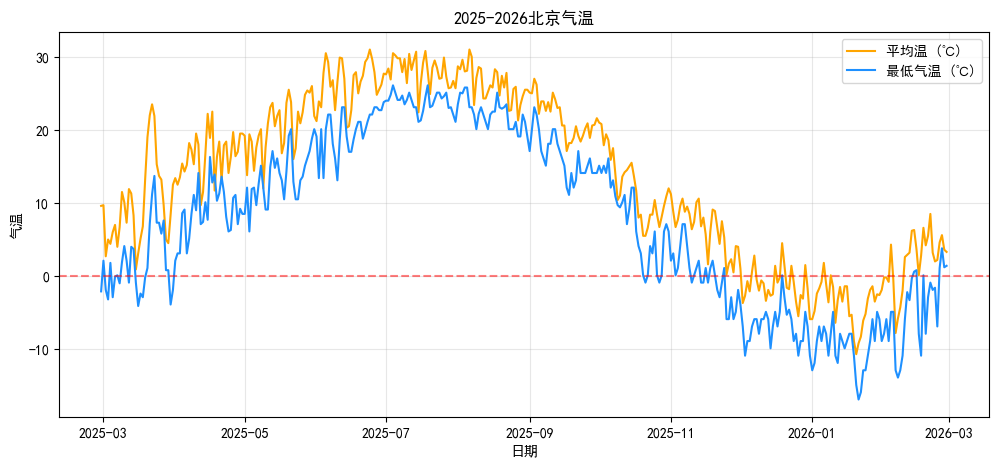

In [6]:
# 3. 简单可视化：看去年冬天北京的降温点
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']      # 指定中文字体
plt.rcParams['axes.unicode_minus'] = False        # 正常显示负号

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['tavg'], label='平均温 (℃)', color='orange')
plt.plot(df.index, df['tmin'], label='最低气温 (℃)', color='dodgerblue')

# 标记冰点0度
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

# 设置图表标题（注意：环境里如果没有中文字体支持会变成方块，可以后续设置）
plt.title('2025-2026北京气温')
plt.xlabel('日期')
plt.ylabel('气温')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()